# Exploratory Data Analysis

This notebook explores restaurant ratings, locations, categories, WiFi availability, review activity, and business performance indicators.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Loading processed dataset from preprocessing notebook
df = pd.read_csv("processed_yelp_restaurants.csv")

df.head()

,business_id,name,city,state,stars,review_count,categories,WiFi_Status
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",u'free'
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,TN,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",u'no'
2,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,Nashville,TN,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",u'no'
3,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Tampa Bay,FL,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",No Info
4,il_Ro8jwPlHresjw9EGmBg,Denny's,Indianapolis,IN,2.5,28,"American (Traditional), Restaurants, Diners, B...",u'no'


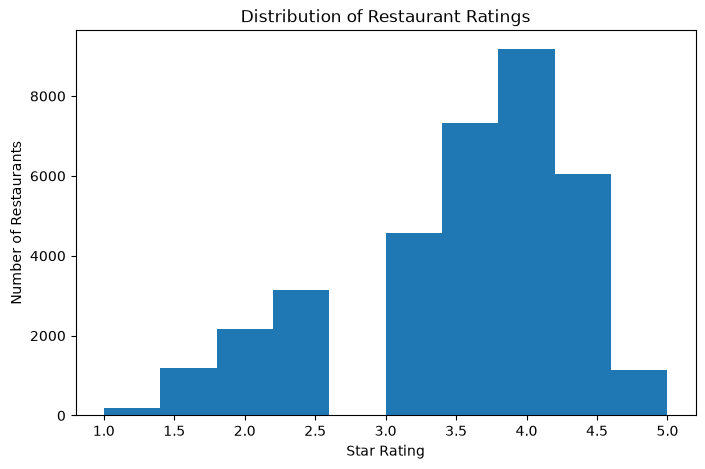

In [4]:
# Plot distribution of restaurant ratings
plt.figure(figsize=(8,5))

plt.hist(df['stars'], bins=10)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Restaurants')

plt.show()

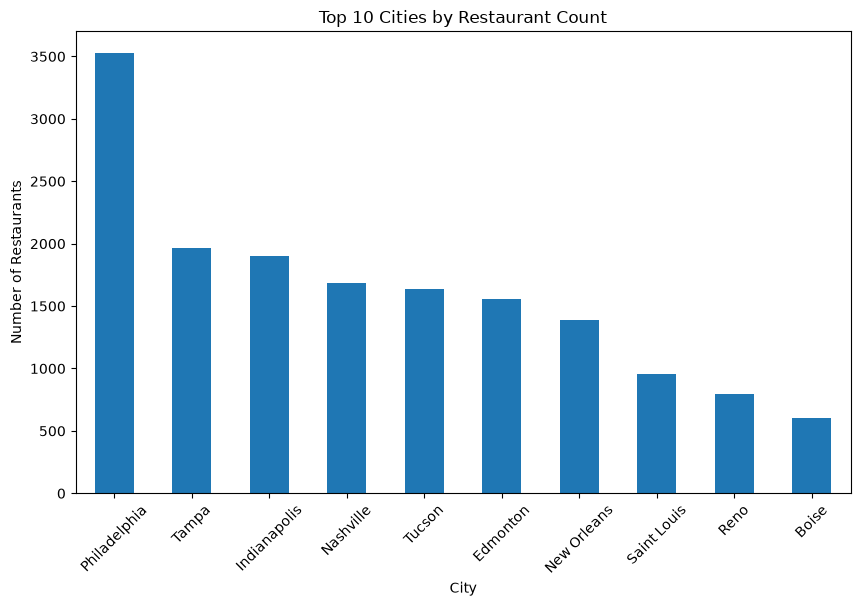

In [ ]:
# Identifying cities with the highest number of restaurants
top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_cities.plot(kind='bar')

plt.title('Top 10 Cities by Restaurant Count')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')

plt.xticks(rotation=45)

plt.show()

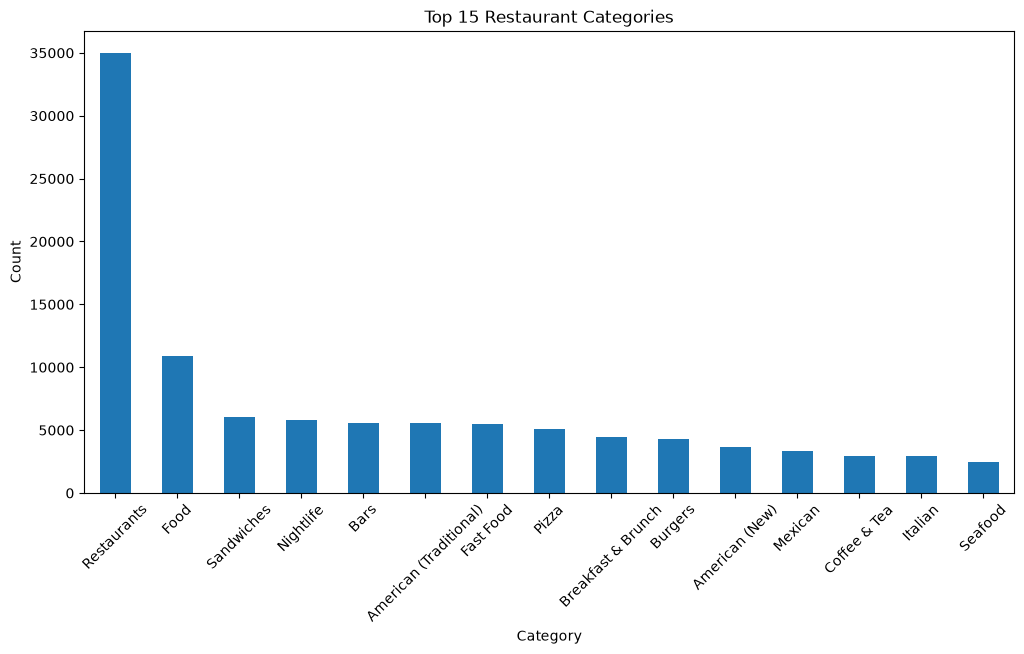

In [ ]:
# Splitting category lists and count individual restaurant categories
all_categories = []

for category_list in df['categories']:
    categories = str(category_list).split(',')
    all_categories.extend([cat.strip() for cat in categories])

category_series = pd.Series(all_categories)

top_categories = category_series.value_counts().head(15)

plt.figure(figsize=(12,6))

top_categories.plot(kind='bar')

plt.title('Top 15 Restaurant Categories')
plt.xlabel('Category')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Calculating average rating by WiFi status
wifi_ratings = df.groupby('WiFi_Status')['stars'].mean().sort_values(ascending=False)

wifi_ratings

WiFi_Status
u'free'    3.711062
u'no'      3.624633
'no'       3.417033
'paid'     3.416667
No Info    3.391035
u'paid'    3.388889
'free'     3.296961
Name: stars, dtype: float64

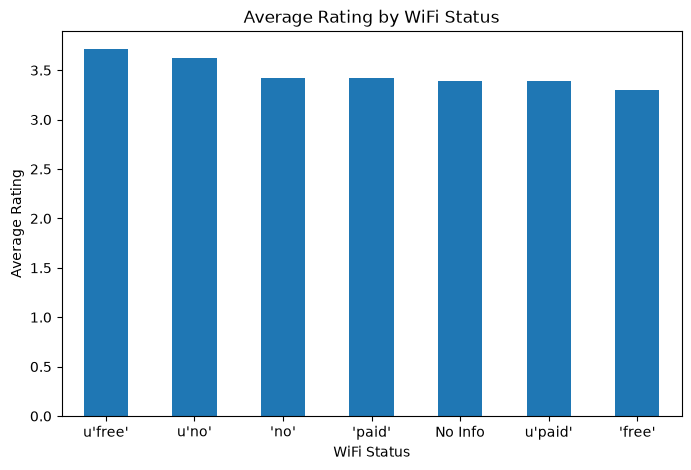

In [ ]:
# Visualising average ratings by WiFi status
plt.figure(figsize=(8,5))

wifi_ratings.plot(kind='bar')

plt.title('Average Rating by WiFi Status')
plt.xlabel('WiFi Status')
plt.ylabel('Average Rating')

plt.xticks(rotation=0)

plt.show()

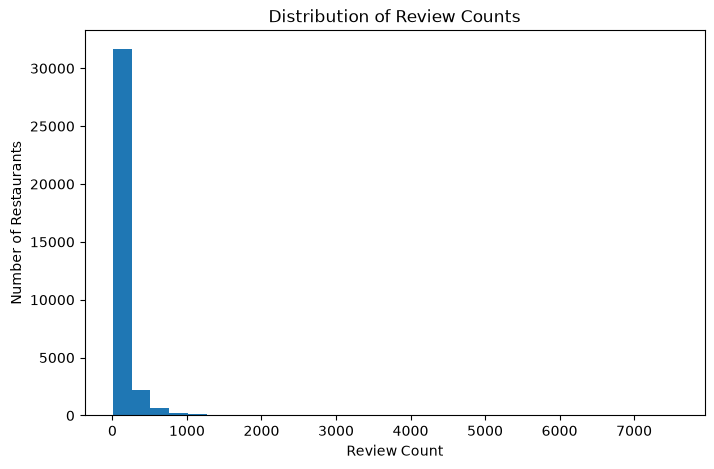

In [9]:
# Plot distribution of review counts
plt.figure(figsize=(8,5))

plt.hist(df['review_count'], bins=30)

plt.title('Distribution of Review Counts')
plt.xlabel('Review Count')
plt.ylabel('Number of Restaurants')

plt.show()

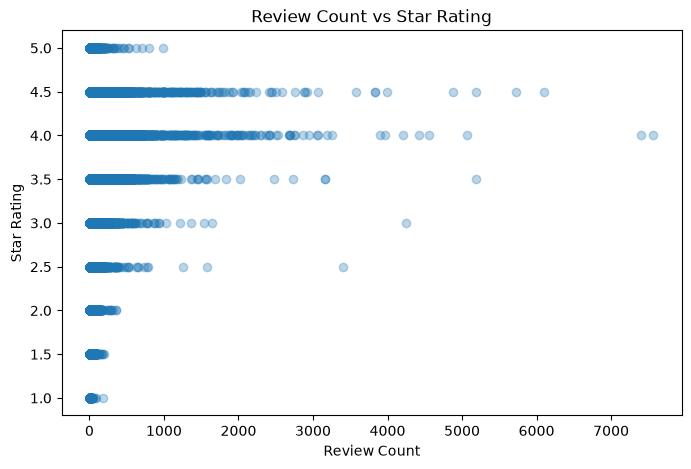

In [ ]:
# Analysing relationship between review count and star rating
plt.figure(figsize=(8,5))

plt.scatter(df['review_count'], df['stars'], alpha=0.3)

plt.title('Review Count vs Star Rating')
plt.xlabel('Review Count')
plt.ylabel('Star Rating')

plt.show()

In [ ]:
# Sorting restaurants by rating and review count
top_restaurants = df.sort_values(
    by=['stars', 'review_count'],
    ascending=[False, False]
)

top_restaurants[['name', 'city', 'stars', 'review_count']].head(10)

,name,city,stars,review_count
2824,Blues City Deli,Saint Louis,5.0,991
31217,Carlillos Cocina,Sparks,5.0,799
3820,Tumerico,Tucson,5.0,705
16353,Yats,Franklin,5.0,623
29231,Smiling With Hope Pizza,Reno,5.0,526
33683,Barracuda Deli Cafe St. Pete Beach,St Pete Beach,5.0,521
1841,Cafe Soleil,St. Pete Beach,5.0,468
7794,Kaffe Crepe,Reno,5.0,454
34570,Buena Onda,Santa Barbara,5.0,414
22122,Big Al's Deli,Nashville,5.0,390


In [ ]:
# Creating popularity score
df['popularity_score'] = df['stars'] * np.log1p(df['review_count'])

top_popular = df.sort_values(
    by='popularity_score',
    ascending=False
)

top_popular[['name', 'city', 'stars', 'review_count', 'popularity_score']].head(10)

,name,city,stars,review_count,popularity_score
21327,Hattie B’s Hot Chicken - Nashville,Nashville,4.5,6093,39.217770
33302,Reading Terminal Market,Philadelphia,4.5,5721,38.934332
34209,Ruby Slipper - New Orleans,New Orleans,4.5,5193,38.498667
7346,Commander's Palace,New Orleans,4.5,4876,38.215285
30860,Pappy's Smokehouse,Saint Louis,4.5,3999,37.323223
11527,Cochon Butcher,New Orleans,4.5,3837,37.137180
30088,Los Agaves,Santa Barbara,4.5,3834,37.133661
16918,Willie Mae's Scotch House,New Orleans,4.5,3582,36.827801
7301,Zahav,Philadelphia,4.5,3065,36.126581
28078,Bern's Steak House,Tampa,4.5,2924,35.914724


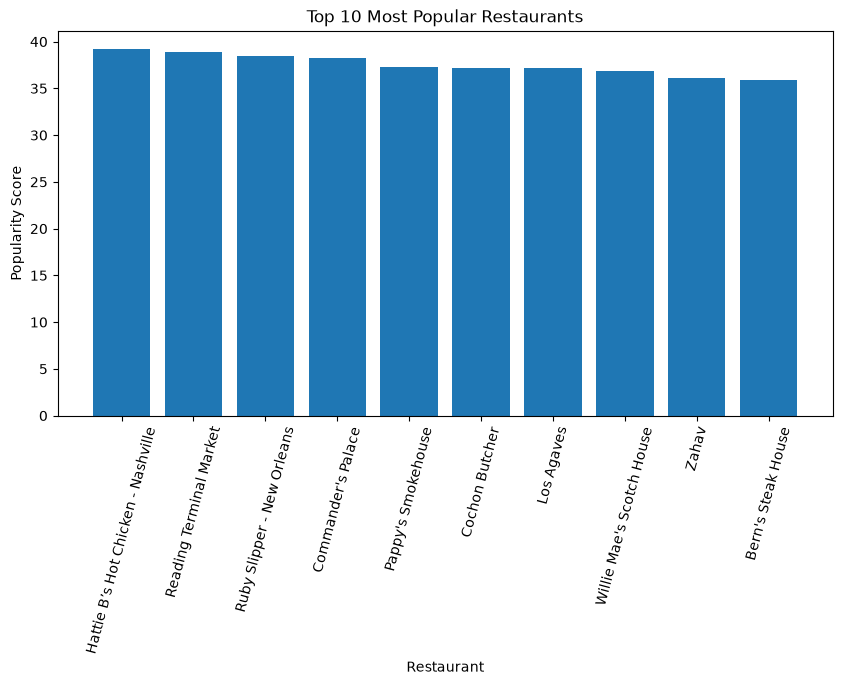

In [ ]:
# Visualising top 10 restaurants by popularity score
top10 = top_popular.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10['name'], top10['popularity_score'])

plt.title('Top 10 Most Popular Restaurants')
plt.xlabel('Restaurant')
plt.ylabel('Popularity Score')

plt.xticks(rotation=75)

plt.show()

## City Performance Analysis

In [14]:
# Calculating city-level average rating, average review count, and number of restaurants
city_rankings = df.groupby('city').agg({
    'stars': 'mean',
    'review_count': 'mean',
    'business_id': 'count'
}).rename(columns={'business_id': 'restaurant_count'})

# Keep cities with at least 50 restaurants to avoid unreliable small samples
city_rankings = city_rankings[city_rankings['restaurant_count'] >= 50]

city_rankings.sort_values(
    by='stars',
    ascending=False
).head(10)

,stars,review_count,restaurant_count
city,,,
Santa Barbara,3.913677,284.905830,446
Dunedin,3.880769,116.953846,130
Carpinteria,3.853448,157.137931,58
Ardmore,3.797101,91.884058,69
Clearwater Beach,3.768519,294.296296,54
New Orleans,3.763480,278.207045,1391
St. Petersburg,3.756917,109.881423,253
Tarpon Springs,3.747312,102.903226,93
Clayton,3.740741,133.166667,54


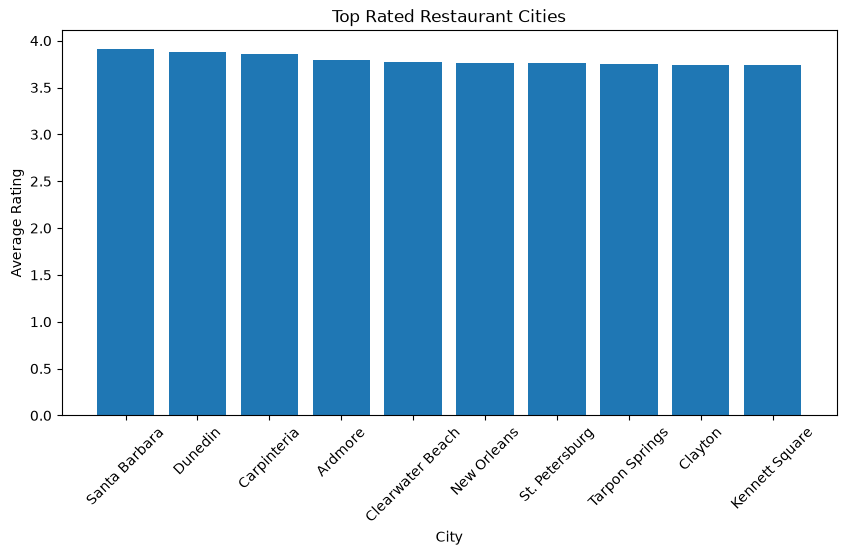

In [15]:
# Visualizing top rated cities
top_rated_cities = city_rankings.sort_values(
    by='stars',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_rated_cities.index, top_rated_cities['stars'])

plt.title('Top Rated Restaurant Cities')
plt.xlabel('City')
plt.ylabel('Average Rating')

plt.xticks(rotation=45)

plt.show()

## Hidden Gem Restaurants

Hidden gems are defined as restaurants with high ratings but relatively low review counts.

In [16]:
# Identify highly rated restaurants with low review counts
hidden_gems = df[
    (df['stars'] >= 4.5) &
    (df['review_count'] < 50)
]

hidden_gems[['name', 'city', 'stars', 'review_count']].head(15)

,name,city,stars,review_count
13,Core de Roma,Bala Cynwyd,5.0,12
16,39 North Taproom & Grill,Glenolden,4.5,25
21,Fresh Fruits & Salads,Camden,4.5,6
23,Impasto,Tampa,5.0,5
24,Silver and Blue Outfitters,Reno,4.5,5
49,The Mad Griddle,Indianapolis,5.0,7
50,530 Pub & Grill,Clearwater,4.5,6
57,Four Green Fields,Tampa,4.5,39
61,Baltic Bakery,Philadelphia,4.5,12
63,The Pepper Pott,Nashville,5.0,18


## State-Level Analysis

In [17]:
# Analysing restaurant count and average rating by state
state_analysis = df.groupby('state').agg({
    'stars': 'mean',
    'business_id': 'count'
}).rename(columns={'business_id': 'restaurant_count'})

state_analysis.sort_values(
    by='restaurant_count',
    ascending=False
).head(10)

,stars,restaurant_count
state,,
PA,3.561470,8069
FL,3.588345,5920
TN,3.459901,3030
IN,3.453279,2836
MO,3.432611,2723
NJ,3.492133,2415
LA,3.593683,2343
AZ,3.449806,1803
AB,3.514706,1734


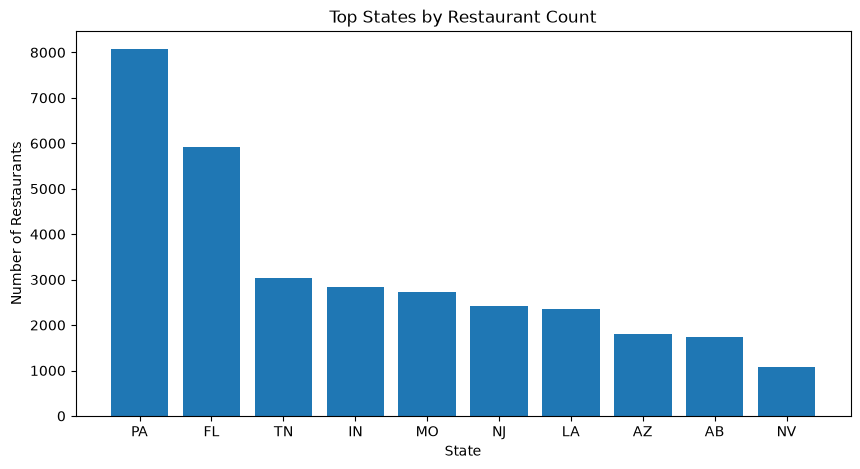

In [18]:
# Visualising top states by restaurant count
top_states = state_analysis.sort_values(
    by='restaurant_count',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_states.index, top_states['restaurant_count'])

plt.title('Top States by Restaurant Count')
plt.xlabel('State')
plt.ylabel('Number of Restaurants')

plt.show()

In [ ]:
#saving dataset for further references with analysis features

In [19]:

df.to_csv("analysis_yelp_restaurants.csv", index=False)

print("Analysis dataset saved successfully.")

Analysis dataset saved successfully.
